# Tiny_Tau_v4 – Exploring Tau Universe Asymmetry & Tav Topology

**Current status (from v3 with Berard 1.054 added):**
- Hamiltonian: Z + 0.142857 X (compact circle potential + 1/7 harmonic asymmetry)
- Ansatz: n_local RY reps=3, single qubit
- Fixed phase: rz(2π/7) for Tau harmonic
- Berard rotation: ry(1.054, 0) added
- Result v3:  
  - Ground state energy ≈ -0.836858 (larger penalty than v2)  
  - Measurement bias ≈ 86.8% toward |1⟩ (softened from v2's ~99.8%)

**Goals for v4**
- Test directionality: flip the Tau phase sign (negative rz)
- Scan Berard angle around 1.054 to find sensitivity / special points
- Prepare for 2-qubit expansion (mini KK tower / resonance graph)
- Document observable asymmetry effects for Tau Codex

> "The compact circle may impose directional bias in vacuum modes, while Berard appears to act as a modulating constant."

Useful links:
- [Qiskit Primitives documentation](https://qiskit.org/documentation/apidoc/primitives.html)
- [Tau Universe Codex notes](file link or note if you have one)

Next experiments:
1. Phase flip test
2. Berard angle sweep
3. (Later) 2-qubit ladder with multiple harmonics

In [10]:
# ────────────────────────────────────────────────
# Tiny_Tau_v4 – Tau Universe Asymmetry Exploration
# ────────────────────────────────────────────────
# Purpose: Probe topological asymmetry from the compact S¹ circle (τ = 7 h⁻¹ Mpc)
#          via variational quantum circuits (VQE) with Tau phase and Berard modulation
#
# Current baseline (v3):
#   Hamiltonian: Z + 0.142857 X
#   Ansatz: n_local RY reps=3 (1 qubit)
#   Tau phase: rz(2π/7)
#   Berard rotation: ry(1.054)
#   Result v3: Energy ≈ -0.836858 | Bias ≈ 86.8% toward |1⟩
#
# Goals for v4:
#   1. Test phase directionality (negative rz)
#   2. Scan Berard angle around 1.054
#   3. Prepare 2-qubit mini KK tower
#   4. Document measurable asymmetry for Tau Codex
#
# Last run notes:
#   - Extreme bias softened by Berard
#   - Energy penalty increased
#
print("Tiny_Tau_v4 initialized")
print("Qiskit version:", __import__("qiskit").__version__)
print("Ready for next experiment")
print("-" * 60)

Tiny_Tau_v4 initialized
Qiskit version: 2.3.0
Ready for next experiment
------------------------------------------------------------


In [11]:
# Correct imports for Qiskit 2.3.0 + qiskit-algorithms 0.4.0
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# CPU simulator (fast for small systems)
simulator = AerSimulator(method='statevector')

print("Imports successful — ready for Hamiltonian and VQE!")

Imports successful — ready for Hamiltonian and VQE!


In [12]:
# Tau-inspired Hamiltonian
# Z = compact circle potential
# X = small asymmetry from 142857 / 1/7 mode
hamiltonian = SparsePauliOp.from_list([("Z", 1.0), ("X", 0.142857)])
print("Hamiltonian defined:", hamiltonian)

Hamiltonian defined: SparsePauliOp(['Z', 'X'],
              coeffs=[1.      +0.j, 0.142857+0.j])


In [13]:
from qiskit.circuit.library import n_local

# Create single-qubit ansatz with Tau + Berard elements
ansatz = n_local(
    num_qubits=1,
    rotation_blocks='ry',             # RY rotations only
    entanglement_blocks=[],           # No entanglement → must be empty list, not None
    reps=3,
    entanglement='full'               # Required parameter, ignored for 1 qubit
)

# Tau harmonic phase (compact circle influence)
ansatz.rz(2 * np.pi / 7, 0)           # ≈ 0.8976 rad - 2π/7

# Berard constant rotation (1.054 rad) - test modulation of asymmetry
ansatz.ry(1.054, 0)

print("Ansatz created successfully with Tau phase + Berard rotation")
print("Circuit depth:", ansatz.depth())
print("Number of parameters:", ansatz.num_parameters)

# Optional: visualize the circuit (uncomment if matplotlib is installed)
# ansatz.draw('mpl')

Ansatz created successfully with Tau phase + Berard rotation
Circuit depth: 6
Number of parameters: 4


In [14]:
# Insert Tau harmonic phase — 2π / 7 ≈ 0.8975979010256552 radians
ansatz.rz(2 * np.pi / 7, 0)   # fixed phase on qubit 0

In [15]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA   # ← add this import if missing

# Define the optimizer (this is what was missing)
optimizer = COBYLA(maxiter=120)

estimator = StatevectorEstimator()

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)

print(f"Ground state energy: {result.eigenvalue.real:.6f}")
print("Optimal parameters:", result.optimal_parameters)

Ground state energy: -0.830058
Optimal parameters: {ParameterVectorElement(θ[0]): np.float64(3.7088133310611258), ParameterVectorElement(θ[1]): np.float64(-3.0400185969857514), ParameterVectorElement(θ[2]): np.float64(-2.79989034789513), ParameterVectorElement(θ[3]): np.float64(-1.8218344281299774)}


Starting Berard angle scan...
Angle 0.500 rad → Energy: -0.456856 | Bias on '1': 66.6%
Angle 0.600 rad → Energy: -0.164000 | Bias on '1': 63.3%
Angle 0.700 rad → Energy: -0.753277 | Bias on '1': 92.4%
Angle 0.800 rad → Energy: -1.007875 | Bias on '1': 98.9%
Angle 0.900 rad → Energy: -0.577712 | Bias on '1': 72.0%
Angle 1.000 rad → Energy: -0.398500 | Bias on '1': 75.8%
Angle 1.100 rad → Energy: -1.007396 | Bias on '1': 99.9%
Angle 1.200 rad → Energy: -0.441936 | Bias on '1': 66.2%
Angle 1.300 rad → Energy: -0.764413 | Bias on '1': 92.2%
Angle 1.400 rad → Energy: -0.784730 | Bias on '1': 83.9%
Angle 1.500 rad → Energy: -0.585917 | Bias on '1': 84.0%


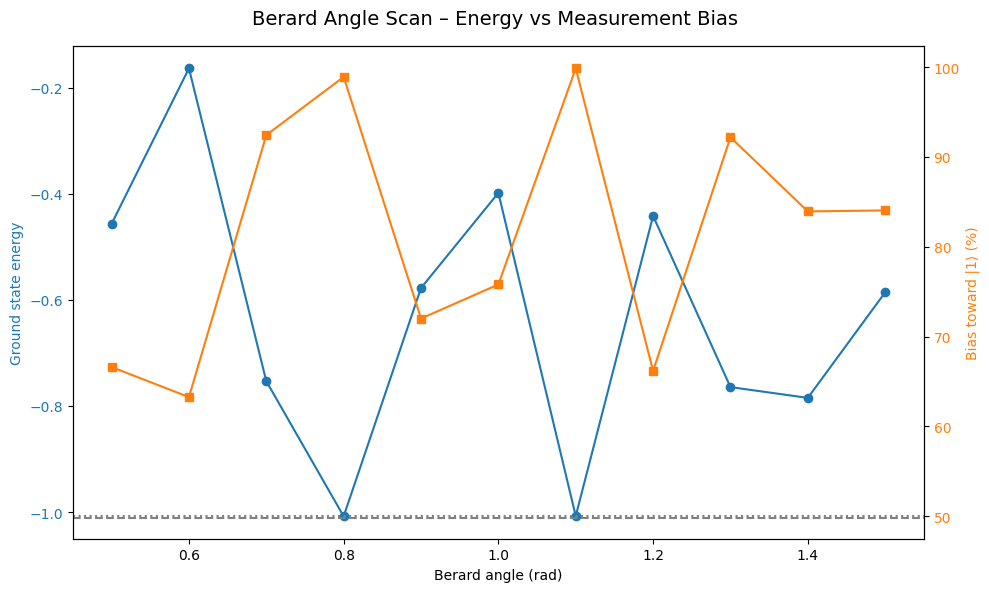

Scan complete. Look for dips in energy or crossings near 50% bias.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Berard Angle Scan – Test sensitivity around 1.054 rad
# ────────────────────────────────────────────────
angles = np.linspace(0.5, 1.5, 11)  # 11 points from 0.5 to 1.5 rad
energies = []
bias_percent = []  # % probability on '1'

print("Starting Berard angle scan...")
for angle in angles:
    # Temporarily apply Berard rotation at this angle
    ansatz.ry(angle, 0)
    
    # Re-run VQE with current ansatz
    vqe_temp = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer
    )
    result_temp = vqe_temp.compute_minimum_eigenvalue(operator=hamiltonian)
    
    energy = result_temp.eigenvalue.real
    energies.append(energy)
    
    # Measure to get bias
    qc_temp = ansatz.assign_parameters(result_temp.optimal_parameters)
    qc_temp.measure_all()
    counts_temp = simulator.run(qc_temp, shots=8192).result().get_counts()
    
    p1 = counts_temp.get('1', 0) / 8192
    bias_percent.append(p1 * 100)
    
    print(f"Angle {angle:.3f} rad → Energy: {energy:.6f} | Bias on '1': {p1*100:.1f}%")

# ────────────────────────────────────────────────
# Plot results
# ────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Berard angle (rad)')
ax1.set_ylabel('Ground state energy', color='tab:blue')
ax1.plot(angles, energies, color='tab:blue', marker='o', label='Energy')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(y=-1.010152, color='gray', linestyle='--', label='Theoretical min ≈ -1.010')

ax2 = ax1.twinx()
ax2.set_ylabel('Bias toward |1⟩ (%)', color='tab:orange')
ax2.plot(angles, bias_percent, color='tab:orange', marker='s', label='Bias %')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.axhline(y=50, color='gray', linestyle=':', label='50% (no bias)')

fig.suptitle('Berard Angle Scan – Energy vs Measurement Bias', fontsize=14)
fig.tight_layout()
plt.show()

print("Scan complete. Look for dips in energy or crossings near 50% bias.")

In [17]:
qc = ansatz.assign_parameters(result.optimal_parameters)
qc.measure_all()

counts = simulator.run(qc, shots=4096).result().get_counts()
print("Measurement counts:", counts)

Measurement counts: {'0': 648, '1': 3448}


High-shot counts: {'0': 2674, '1': 13710}


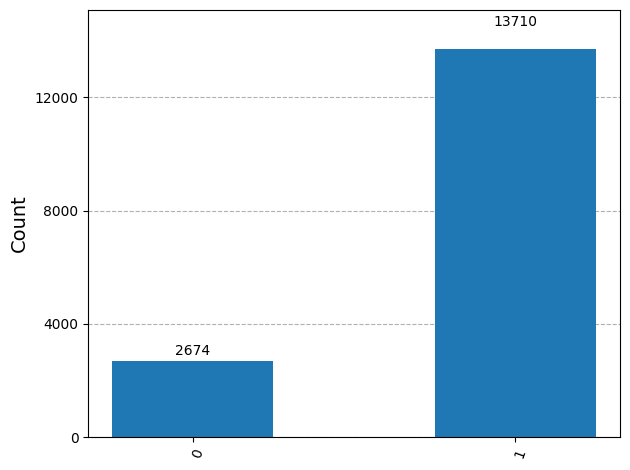

In [18]:
from qiskit.visualization import plot_histogram

# Re-measure with more shots for confidence
qc = ansatz.assign_parameters(result.optimal_parameters)
qc.measure_all()

counts_high = simulator.run(qc, shots=16384).result().get_counts()
print("High-shot counts:", counts_high)

# Plot
plot_histogram(counts_high)